<a href="https://colab.research.google.com/github/anasshwahen442-code/fmri-first-level-glm/blob/main/fmri_first_level_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-fMRI GLM analysis of a public language-localizer dataset

Reproducible first-level, group-level and ROI analysis with Nilearn.
Data: Nilearn language-localizer demo dataset (10 subjects). Preprocessing
(realignment, MNI normalisation) was done by the dataset authors, not here.


In [37]:
!pip install -q nilearn

In [38]:
from nilearn.datasets import fetch_language_localizer_demo_dataset
data = fetch_language_localizer_demo_dataset()
print(data.data_dir)

[fetch_language_localizer_demo_dataset] Dataset directory found: /root/nilearn_data/fMRI-language-localizer-demo-dataset

/root/nilearn_data/fMRI-language-localizer-demo-dataset


In [39]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from nilearn import datasets, image, plotting
from nilearn.glm import threshold_stats_img
from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm.second_level import SecondLevelModel
from nilearn.maskers import NiftiMasker

root = Path(data.data_dir)
subs = [f"sub-{i:02d}" for i in range(1, 11)]
MOTION = ["X", "Y", "Z", "RotX", "RotY", "RotZ"]  # motion parameters only

def fit_subject(sub, fwhm=8):
    func = root / "derivatives" / sub / "func"
    stem = f"{sub}_task-languagelocalizer"
    bold = func / f"{stem}_desc-preproc_bold.nii.gz"
    meta = json.load(open(func / f"{stem}_desc-preproc_bold.json"))
    events = pd.read_csv(root / sub / "func" / f"{stem}_events.tsv", sep="\t")
    conf = pd.read_csv(func / f"{stem}_desc-confounds_regressors.tsv", sep="\t")
    motion = conf[[c for c in MOTION if c in conf.columns]].fillna(0)
    model = FirstLevelModel(t_r=meta["RepetitionTime"], hrf_model="spm",
                            drift_model="cosine", high_pass=1/128,
                            smoothing_fwhm=fwhm, noise_model="ar1")
    return model.fit(str(bold), events=events, confounds=motion)

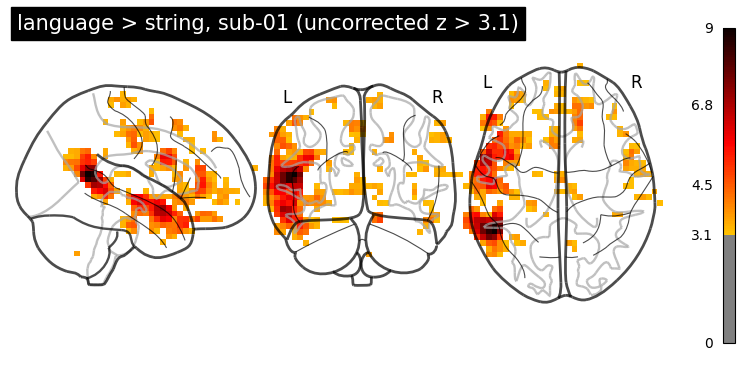

In [41]:
model_01 = fit_subject("sub-01")
z_01 = model_01.compute_contrast("language - string", output_type="z_score")
plotting.plot_glass_brain(z_01, threshold=3.1, colorbar=True,
                          title="language > string, sub-01 (uncorrected z > 3.1)")
plotting.show()

FDR q<0.05 threshold: 2.960409761089666


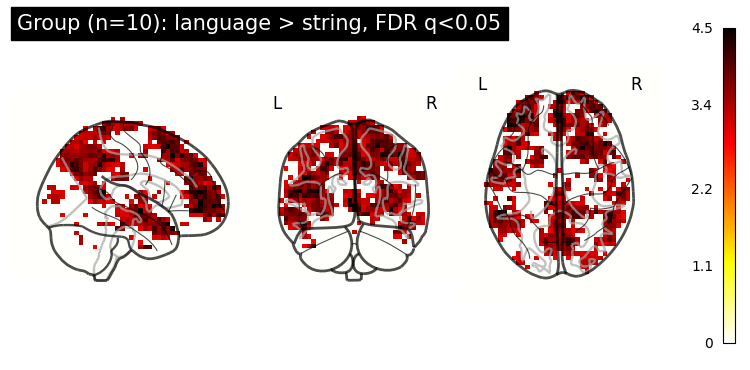

In [32]:
effect_maps = [fit_subject(s).compute_contrast("language - string",
                                               output_type="effect_size")
               for s in subs]

design = pd.DataFrame([1] * len(effect_maps), columns=["intercept"])
slm = SecondLevelModel().fit(effect_maps, design_matrix=design)
z_group = slm.compute_contrast("intercept", output_type="z_score")

thr_img, thr = threshold_stats_img(z_group, alpha=0.05, height_control="fdr")
print("FDR q<0.05 threshold:", thr)
plotting.plot_glass_brain(thr_img, colorbar=True,
                          title="Group (n=10): language > string, FDR q<0.05")
plotting.show()

FDR q<0.05 threshold: 2.960409761089666


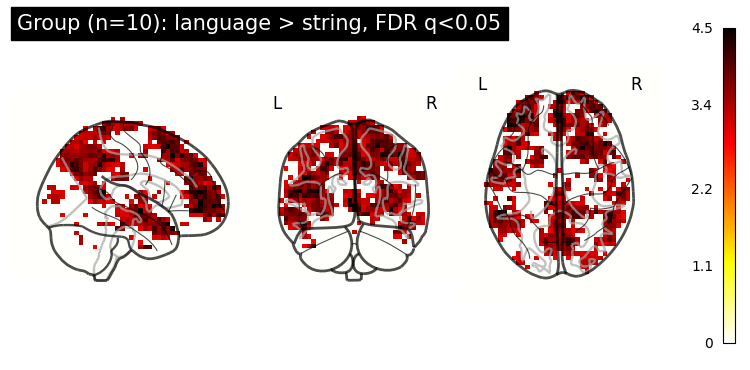

In [33]:
effect_maps = [fit_subject(s).compute_contrast("language - string",
                                               output_type="effect_size")
               for s in subs]

design = pd.DataFrame([1] * len(effect_maps), columns=["intercept"])
slm = SecondLevelModel().fit(effect_maps, design_matrix=design)
z_group = slm.compute_contrast("intercept", output_type="z_score")

thr_img, thr = threshold_stats_img(z_group, alpha=0.05, height_control="fdr")
print("FDR q<0.05 threshold:", thr)
plotting.plot_glass_brain(thr_img, colorbar=True,
                          title="Group (n=10): language > string, FDR q<0.05")
plotting.show()

## Pre-specified hypotheses (written 7 Oct 2026, before the ROI analysis)

ROIs were chosen from the language-localizer literature before extracting any values.
The whole-brain maps above had already been viewed.

H1: The mean effect for "language > string" is positive in the left inferior frontal
gyrus (IFG) and the left superior temporal gyrus (STG).
Test: one-sample t-test across subjects (n = 10), Bonferroni-corrected over 4 ROIs.

H2 (control): no reliable effect in the left and right hippocampus.
A non-significant result here is not evidence of absence, given n = 10.

All results are reported below, whether or not they support these hypotheses.

In [42]:
cort = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
subc = datasets.fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm")

def labels_containing(atlas, text):
    return [l for l in atlas.labels if text.lower() in l.lower()]

def build_roi(atlas, names, hemisphere=None):
    labels = list(atlas.labels)
    idx = [labels.index(n) for n in names]
    img = image.load_img(atlas.maps)
    data_ = img.get_fdata()
    mask = np.isin(data_, idx)
    if hemisphere in ("left", "right"):
        i, j, k = np.indices(data_.shape)
        x = (img.affine[0, 0] * i + img.affine[0, 1] * j
             + img.affine[0, 2] * k + img.affine[0, 3])
        mask &= (x < 0) if hemisphere == "left" else (x > 0)
    return image.new_img_like(img, mask.astype("int8"))

rois = {
    "L IFG": build_roi(cort, labels_containing(cort, "Inferior Frontal Gyrus"), "left"),
    "L STG": build_roi(cort, labels_containing(cort, "Superior Temporal Gyrus"), "left"),
    "L hippocampus": build_roi(subc, labels_containing(subc, "Left Hippocampus")),
    "R hippocampus": build_roi(subc, labels_containing(subc, "Right Hippocampus")),
}

[fetch_atlas_harvard_oxford] Dataset directory found: /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Dataset directory found: /root/nilearn_data/fsl

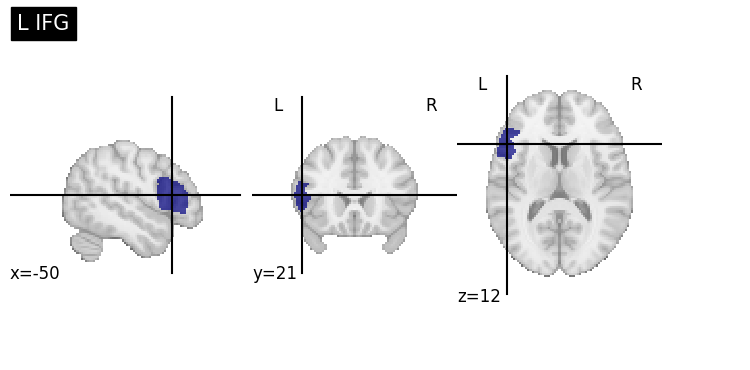

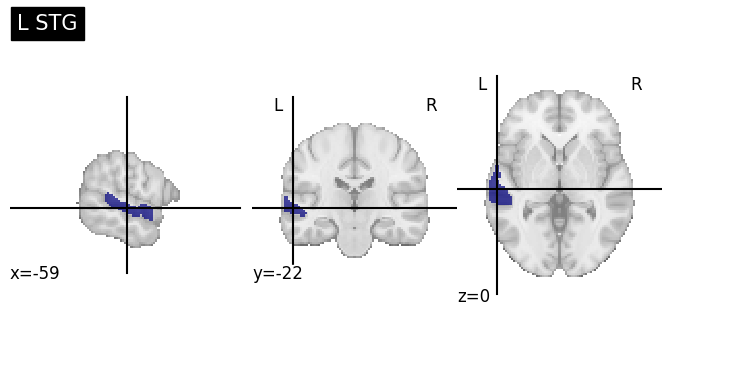

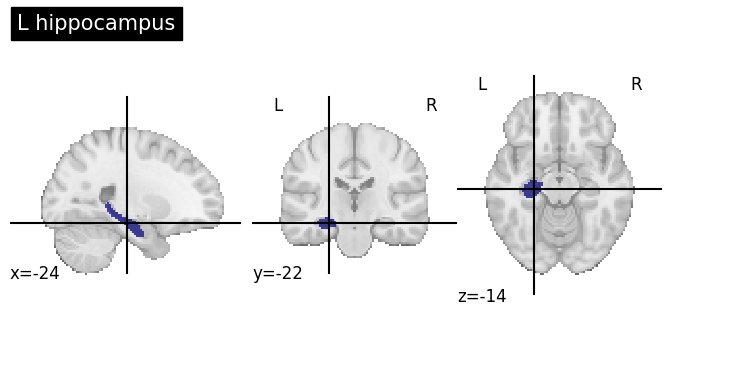

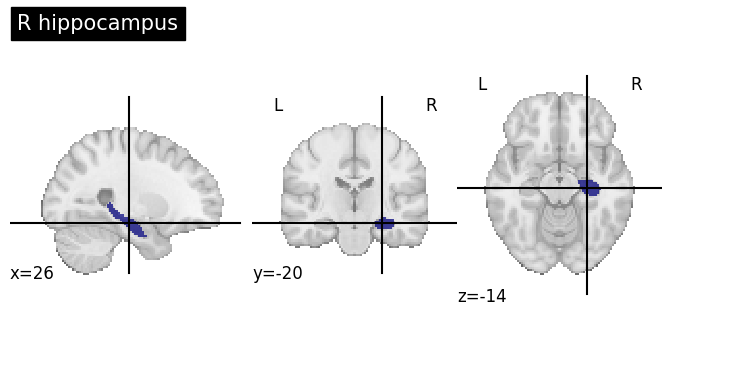

In [43]:
for name, roi in rois.items():
    plotting.plot_roi(roi, title=name, display_mode="ortho")
plotting.show()

In [44]:
def roi_mean(effect_img, roi_img):
    roi_rs = image.resample_to_img(roi_img, effect_img, interpolation="nearest")
    masker = NiftiMasker(mask_img=roi_rs, standardize=None).fit()
    return masker.transform(effect_img).mean()

rows = []
for name, roi in rois.items():
    vals = np.array([roi_mean(e, roi) for e in effect_maps])
    t, p = stats.ttest_1samp(vals, 0)
    d = vals.mean() / vals.std(ddof=1)
    lo, hi = stats.t.interval(0.95, len(vals) - 1,
                              loc=vals.mean(), scale=stats.sem(vals))
    rows.append((name, vals.mean(), lo, hi, t, p, min(p * len(rois), 1.0), d))

table = pd.DataFrame(rows, columns=["ROI", "mean effect", "CI low", "CI high",
                                    "t(9)", "p", "p (Bonferroni)", "Cohen's d"])
print(table.round(4).to_string(index=False))

          ROI  mean effect  CI low  CI high   t(9)      p  p (Bonferroni)  Cohen's d
        L IFG       0.1283  0.0370   0.2196 3.1776 0.0112          0.0449     1.0048
        L STG       0.3257  0.1834   0.4679 5.1797 0.0006          0.0023     1.6380
L hippocampus       0.0031 -0.0313   0.0376 0.2065 0.8410          1.0000     0.0653
R hippocampus       0.0026 -0.0237   0.0288 0.2213 0.8298          1.0000     0.0700
